## 1. Problem Tanımı ve Amaç

Bu projede, bankaya ait müşteri verileri kullanılarak
müşterilerin bankadan ayrılıp ayrılmayacağını 
tahmin etmek amaçlanmaktadır.

Amaç, makine öğrenmesi ve yapay sinir ağları kullanarak
müşteri kaybını önceden tahmin edebilecek bir model
geliştirmek ve farklı algoritmaların performanslarını
karşılaştırmaktır.


## 2. Veri Seti

Kullanılan veri seti Kaggle üzerinden temin edilen
**Churn_Modelling.csv** dosyasıdır.
Veri seti, banka müşterilerine ait bazı bilgiler,
hesap bilgileri ve müşterinin bankadan ayrılıp ayrılmadığı
bilgisini içermektedir.

Hedef değişken: **Exited**
- 0: Bankada kalan müşteri
- 1: Bankadan ayrılan müşteri


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


## 3. Veri Ön İşleme

Veri setindeki gereksiz sütunlar kaldırılmış,
kategorik değişkenler sayısal forma dönüştürülmüş
ve modelleme için uygun hale getirilmiştir.


In [3]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Kategorik Değişken Analizi

Veri setindeki kategorik değişkenler belirlenmiş ve
her birinin sahip olduğu benzersiz kategori sayısı incelenmiştir.
Bu adım, uygun kodlama  yönteminin seçilmesi için
önemlidir.


In [14]:
# Kategorik değişkenlerin belirlenmesi
# Bu adım, encoding işleminden önce yapılmalıdır
categorical_cols = df.select_dtypes(include=['object']).columns

# Her kategorik değişkenin sahip olduğu benzersiz kategori sayısı
{col: df[col].nunique() for col in categorical_cols}


{'Surname': 2932, 'Geography': 3, 'Gender': 2}

In [15]:
# Gereksiz sütunları çıkarıyoruz
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


Bu veri seti toplam **10000 satır** ve **14 sütundan** oluşmaktadır.
Satırlar banka müşterilerini, sütunlar ise müşteri özelliklerini
ve hedef değişkeni temsil etmektedir.


In [16]:
# Veri setinin satır ve sütun sayısını görüntüle
df.shape


(10000, 12)

Veri setinin yapısı incelendiğinde, hem sayısal hem de
kategorik değişkenler içerdiği görülmektedir.
Bu nedenle kategorik değişkenler modelleme öncesinde
sayısal forma dönüştürülmüştür.


In [17]:
# Değişkenlerin veri tiplerini inceleyerek kategorik ve sayısal sütunları belirlemek için
df.dtypes


CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object

### Eksik Değer Analizi

Veri setinde eksik (null) değer olup olmadığı kontrol edilmiştir.
Eksik değer bulunmaması, veri setinin doğrudan modellemeye
uygun olduğunu göstermektedir.


In [18]:
# Veri setinde eksik (null) değer olup olmadığını kontrol ediyoruz
df.isnull().sum()


CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64

### Temel İstatistiksel Analiz

Sayısal değişkenler için ortalama, standart sapma,
minimum ve maksimum değerler incelenmiştir.
Bu analiz, verilerin dağılımı ve olası aykırı değerler
hakkında genel bir fikir vermektedir.


In [19]:
# Temel istatistikler
df.describe()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Yaş Dağılımının İncelenmesi

Bu görselleştirme ile veri setindeki müşterilerin yaş dağılımı
incelenmiştir. Yaş değişkeninin dağılımı, müşteri profilinin
anlaşılması açısından önemlidir. Aykırı değerler ve yoğunluk
bölgeleri bu grafik sayesinde gözlemlenebilmektedir.


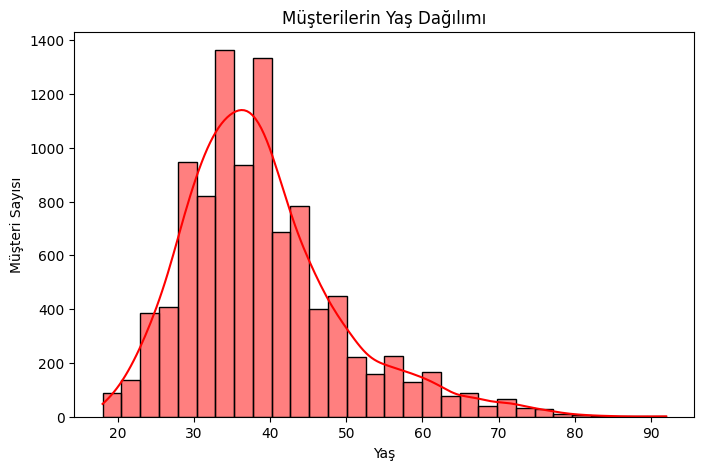

In [20]:
# Yaş değişkeninin dağılımını incelemek için histogram çizimi
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='red')

# Grafik başlık ve eksen isimleri
plt.title("Müşterilerin Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Müşteri Sayısı")

plt.show()


### Cinsiyete Göre Müşteri Ayrılma Analizi

Bu grafik, müşterilerin cinsiyetlerine göre
bankadan ayrılma durumlarını göstermektedir.
Görsel analiz sayesinde, cinsiyet değişkeninin
müşteri kaybı üzerindeki etkisi gözlemlenmiştir.


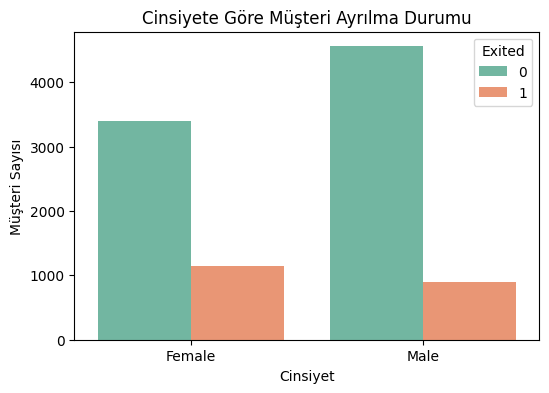

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df, palette='Set2')
plt.title("Cinsiyete Göre Müşteri Ayrılma Durumu")
plt.xlabel("Cinsiyet")
plt.ylabel("Müşteri Sayısı")
plt.show()


### Ülkeye Göre Müşteri Ayrılma Analizi

Bu grafik, müşterilerin bulundukları ülkelere göre
bankadan ayrılma (churn) durumlarını göstermektedir.
Görsel analiz sonucunda, bazı ülkelerde müşteri
kaybının diğer ülkelere kıyasla daha yüksek olduğu
gözlemlenmiştir.

Bu durum, coğrafi faktörlerin müşteri davranışı
üzerinde etkili olabileceğini göstermektedir.


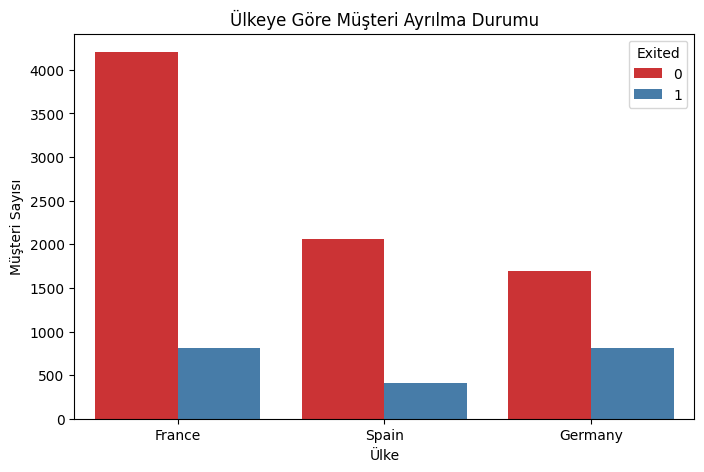

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik boyutunun ayarlanması
plt.figure(figsize=(8,5))

# Ülkelere göre müşteri sayısı ve churn (Exited) durumunun görselleştirilmesi
# Hue parametresi ile bankadan ayrılan (1) ve ayrılmayan (0) müşteriler ayrıştırılır
sns.countplot(
    x='Geography',
    hue='Exited',
    data=df,
    palette='Set1'
)

# Grafik başlığı
plt.title("Ülkeye Göre Müşteri Ayrılma Durumu")

# Eksen etiketleri
plt.xlabel("Ülke")
plt.ylabel("Müşteri Sayısı")

# Grafiğin gösterilmesi
plt.show()


### Sayısal Değişkenler Arası Korelasyon Analizi

Bu bölümde, veri setinde yer alan sayısal değişkenler arasındaki
ilişkiler incelenmiştir. Korelasyon matrisi sayesinde değişkenlerin
birbirleriyle olan doğrusal ilişkileri görsel olarak analiz edilmiştir.

Isı haritasında:
- 1’e yakın değerler güçlü pozitif ilişkiyi,
- -1’e yakın değerler güçlü negatif ilişkiyi,
- 0’a yakın değerler ise zayıf ilişkiyi ifade etmektedir.

Bu analiz, modelleme aşamasında hangi değişkenlerin hedef değişken
üzerinde daha etkili olabileceğini anlamak için kullanılmıştır.


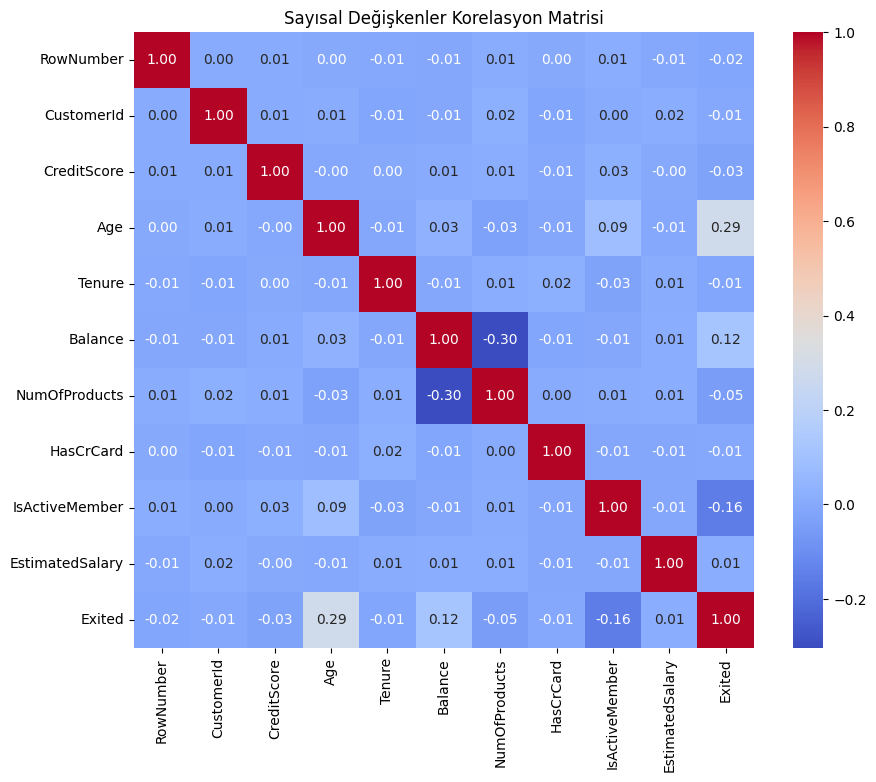

In [ ]:
plt.figure(figsize=(10,8))

# Veri setindeki sayısal sütunların seçilmesi
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Sayısal değişkenler arasındaki korelasyon matrisinin hesaplanması
corr_matrix = df[numerical_cols].corr()

# Korelasyon matrisinin ısı haritası (heatmap) ile görselleştirilmesi
sns.heatmap(
    corr_matrix,
    annot=True,          # Korelasyon değerlerini hücre içinde göster
    fmt=".2f",           # Ondalık gösterim formatı
    cmap="coolwarm",     # Renk skalası
    cbar=True            # Renk çubuğunu göster
)

# Grafik başlığı
plt.title("Sayısal Değişkenler Korelasyon Matrisi")

plt.show()


### Yaş (Age) ve Müşteri Ayrılma Analizi

Bu grafik, müşterilerin yaş dağılımlarını
bankadan ayrılma durumuna (Exited) göre göstermektedir.

Grafikten görüldüğü üzere, bankadan ayrılan müşterilerin
genellikle daha ileri yaş grubunda yoğunlaştığı gözlemlenmiştir.
Bu durum, yaş değişkeninin müşteri kaybı üzerinde
önemli bir etkiye sahip olabileceğini göstermektedir.

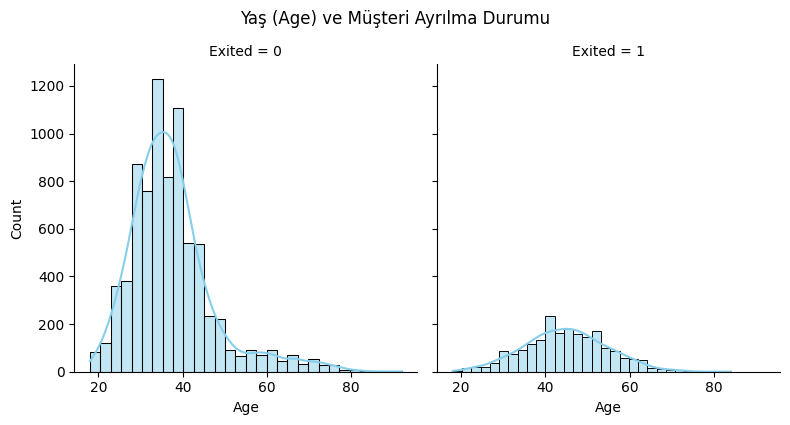

In [ ]:
g = sns.FacetGrid(df, col='Exited', height=4, aspect=1)
g.map(sns.histplot, 'Age', bins=30, kde=True, color='skyblue')
g.fig.suptitle("Yaş (Age) ve Müşteri Ayrılma Durumu", y=1.05)
plt.show()


### Bankada Kalma Süresi (Tenure) ve Müşteri Ayrılma Analizi

Bu grafik, müşterilerin bankada kaç yıldır
bulunduklarını ve bu durumun müşteri ayrılma
üzerindeki etkisini göstermektedir.

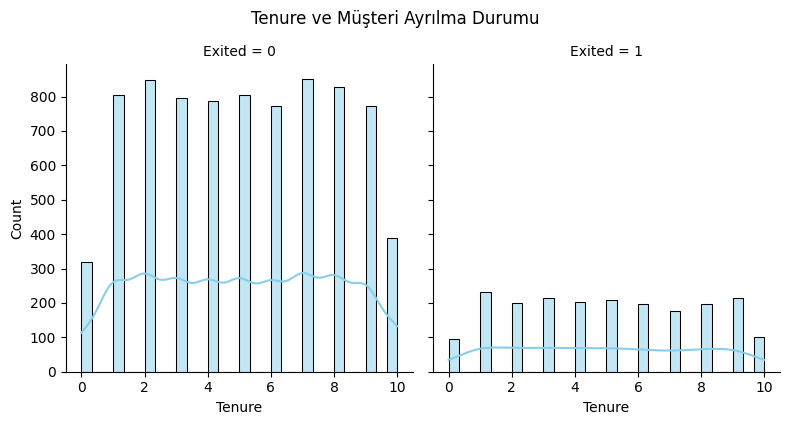

In [ ]:
g = sns.FacetGrid(df, col='Exited', height=4, aspect=1)
g.map(sns.histplot, 'Tenure', bins=30, kde=True, color='skyblue')
g.fig.suptitle("Tenure ve Müşteri Ayrılma Durumu", y=1.05)
plt.show()


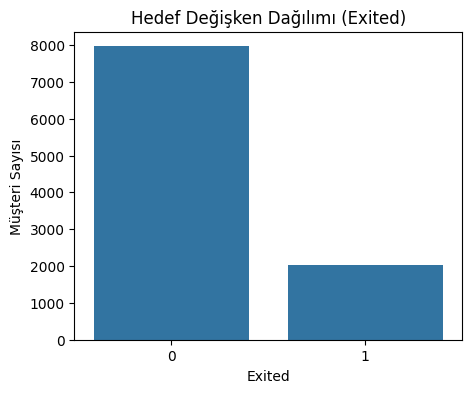

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Exited', data=df)
plt.title("Hedef Değişken Dağılımı (Exited)")
plt.xlabel("Exited")
plt.ylabel("Müşteri Sayısı")
plt.show()


### Bakiye Değişkeninin Müşteri Kaybına Etkisi

Grafik incelendiğinde, yüksek bakiyeye sahip
müşterilerin bankadan ayrılma olasılığının
daha yüksek olduğu gözlemlenmektedir.
Bu durum, yüksek bakiyeli müşterilerin
daha dikkatli analiz edilmesi gerektiğini göstermektedir.

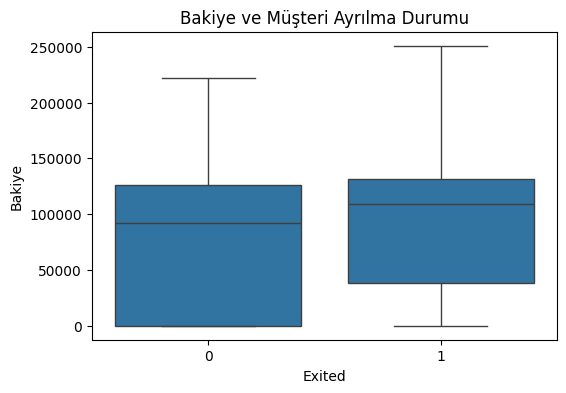

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Bakiye ve Müşteri Ayrılma Durumu")
plt.xlabel("Exited")
plt.ylabel("Bakiye")
plt.show()


### Ülkelere Göre Müşteri Ayrılma Oranı

Bu grafik, her ülke için bankadan ayrılan
müşterilerin toplam müşterilere oranını
göstermektedir. Sayısal oranlar üzerinden
yorum yapmak, sadece müşteri sayısına
bakmaktan daha sağlıklı sonuçlar sunmaktadır.


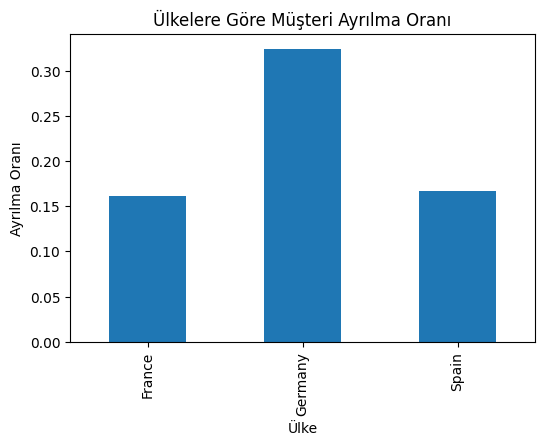

In [7]:
churn_rate_geo = df.groupby("Geography")["Exited"].mean()

churn_rate_geo.plot(kind="bar", figsize=(6,4))
plt.title("Ülkelere Göre Müşteri Ayrılma Oranı")
plt.xlabel("Ülke")
plt.ylabel("Ayrılma Oranı")
plt.show()


## Modelleme Öncesi Hazırlık

Bu aşamada makine öğrenmesi modellerinin
doğru ve adil şekilde eğitilebilmesi için
veri seti modele uygun hale getirilmiştir.

Bu kapsamda:
- Kategorik değişkenler sayısal forma dönüştürülmüştür
- Bağımsız ve bağımlı değişkenler ayrılmıştır
- Veri eğitim ve test setlerine bölünmüştür
- Bazı modeller için ölçekleme uygulanmıştır


In [10]:
df = pd.get_dummies(df, drop_first=True)


In [8]:
# Bağımsız değişkenler (özellikler)
X = df.drop("Exited", axis=1)

# Hedef değişken
y = df["Exited"]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 4. Makine Öğrenmesi Modellerinin Uygulanması

Bu bölümde, müşteri kaybı  tahmin problemi için
farklı makine öğrenmesi algoritmaları kullanılarak
tahmin modelleri oluşturulmuştur.

Amaç, farklı algoritmaların performanslarını karşılaştırmak
ve hangi modelin müşteri kaybını daha başarılı bir şekilde
tahmin ettiğini belirlemektir.

Çalışma kapsamında aşağıdaki modeller uygulanacaktır:

- Naive Bayes
- Decision Tree (Karar Ağacı)
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Linear Regression (Sınıflandırma amacıyla)
- Yapay Sinir Ağları (ANN)

Her model için aşağıdaki adımlar izlenecektir:
- Modelin eğitilmesi (training)
- Test verisi üzerinde tahmin yapılması
- Confusion Matrix oluşturulması
- Accuracy, Precision, Recall ve F1-score metriklerinin hesaplanması
- Modellerin performanslarının karşılaştırılması

Bu sayede, müşteri kaybı  problemleri için en uygun modelin
belirlenmesi hedeflenmektedir.


In [10]:
# Hedef değişken (çıktı)
y = df['Exited']

# Bağımsız değişkenler (girdiler)
X = df.drop('Exited', axis=1)


In [11]:
# Kategorik değişkenlerin one-hot encoding ile dönüştürülmesi
X = pd.get_dummies(X, drop_first=True)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Naive Bayes Algoritması

Naive Bayes, olasılık temelli bir sınıflandırma algoritmasıdır ve
Bayes Teoremi’ne dayanır. Algoritmanın temel varsayımı,
özelliklerin (değişkenlerin) birbirinden **bağımsız** olduğudur.
Bu varsayım gerçek hayatta her zaman tam olarak sağlanmasa da,
Naive Bayes birçok problemde başarılı sonuçlar vermektedir.

Bu projede kullanılan **Gaussian Naive Bayes** modeli,
sayısal değişkenlerin normal (Gaussian) dağılıma sahip olduğunu varsayar.

Naive Bayes modeli, bir müşterinin bankadan ayrılma olasılığını
(Exited = 1) veya ayrılmama olasılığını (Exited = 0),
özelliklerin koşullu olasılıklarını hesaplayarak tahmin eder.

Avantajları:
- Hızlı ve basit bir algoritmadır
- Büyük veri setlerinde etkilidir
- Başlangıç seviyesi için güçlü bir referans modeldir

Bu nedenle Naive Bayes, diğer modellerle karşılaştırma yapmak
amacıyla projede ilk model olarak tercih edilmiştir.


In [11]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes modelinin oluşturulması
nb_model = GaussianNB()

# Modelin eğitilmesi
nb_model.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [12]:
# Test verisi üzerinde tahmin
y_pred_nb = nb_model.predict(X_test)


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Classification Report
print("Naive Bayes Classification Report")
print(classification_report(y_test, y_pred_nb))


Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1593
           1       0.33      0.06      0.10       407

    accuracy                           0.78      2000
   macro avg       0.56      0.51      0.49      2000
weighted avg       0.70      0.78      0.72      2000



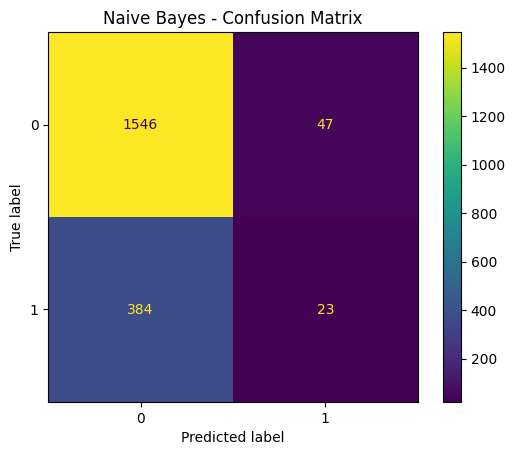

In [14]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

ConfusionMatrixDisplay(cm_nb).plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()


### Naive Bayes Modeli – Sonuçların Değerlendirilmesi

Naive Bayes modeli kullanılarak yapılan sınıflandırma sonucunda
elde edilen performans metrikleri incelendiğinde, modelin özellikle
**bankada kalan müşterileri (Exited = 0)** tahmin etmede başarılı olduğu,
ancak **bankadan ayrılan müşterileri (Exited = 1)** yakalamakta yetersiz
kaldığı görülmektedir.

Modelin genel doğruluk (accuracy) değeri **%78** olarak hesaplanmıştır.
Bu değer ilk bakışta kabul edilebilir görünse de, churn problemi için
tek başına yeterli değildir. Çünkü bu tür problemlerde asıl önemli olan,
bankadan ayrılacak müşterilerin doğru şekilde tespit edilebilmesidir.

Precision değeri churn sınıfı (Exited = 1) için **0.33** olarak bulunmuştur.
Bu durum, modelin “ayrılacak” dediği müşterilerin yalnızca üçte birinin
gerçekten bankadan ayrıldığını göstermektedir. Recall değerinin ise
**0.06** gibi oldukça düşük olması, modelin bankadan ayrılan müşterilerin
çok büyük bir kısmını tespit edemediğini ortaya koymaktadır.

F1-score değerinin churn sınıfı için **0.10** olması, precision ve recall
değerlerinin dengesiz ve zayıf olduğunu doğrulamaktadır. Bu sonuçlar,
Naive Bayes modelinin bu veri seti üzerinde churn tahmini için
tek başına yeterli olmadığını göstermektedir.

Sonuç olarak, Naive Bayes modeli temel ve hızlı bir algoritma olmasına
rağmen, churn gibi dengesiz sınıf dağılımına sahip problemlerde
yetersiz kalabilmektedir. Bu nedenle, daha karmaşık modeller
(Decision Tree, SVM, KNN ve Yapay Sinir Ağları gibi) ile karşılaştırma
yapılması gerekli görülmektedir.


## Decision Tree (Karar Ağacı) Modeli

### Modelin Çalışma Mantığı

Decision Tree (Karar Ağacı), sınıflandırma problemlerinde
en sık kullanılan denetimli öğrenme algoritmalarından biridir.
Bu algoritma, veriyi belirli kurallara göre dallara ayırarak
karar verme sürecini ağaç yapısı üzerinde gerçekleştirir.

Model, her düğümde veri setini en iyi ayıran özelliği seçer.
Bu seçim sırasında genellikle **Gini Index** veya **Entropy**
gibi ölçütler kullanılır. Amaç, alt dallarda mümkün olduğunca
 aynı sınıfa ait örnekler elde etmektir.

Ağaç yapısında:
- **Kök düğüm**, en bilgilendirici özelliği temsil eder
- **Dallar**, karar kurallarını ifade eder
- **Yaprak düğümler**, nihai sınıf tahminini gösterir

Bu yapı sayesinde Decision Tree modeli,
karmaşık karar mekanizmalarını kolayca
yorumlanabilir kurallara dönüştürür.

---


### Modelin Avantajları ve Dezavantajları

**Avantajlar**
- Kolay anlaşılır ve yorumlanabilir
- Ön işleme ihtiyacı düşüktür
- Hem sınıflandırma hem regresyon problemlerinde kullanılabilir

**Dezavantajlar**
- Derin ağaçlarda overfitting riski vardır
- Küçük veri değişimlerine karşı hassas olabilir

Bu nedenle modelde maksimum derinlik 
sınırlandırılarak daha dengeli bir yapı elde edilmiştir.


In [16]:
from sklearn.tree import DecisionTreeClassifier

# Karar ağacı modelinin oluşturulması
dt_model = DecisionTreeClassifier(
    criterion="gini",     # Saflık ölçütü
    max_depth=5,          # Aşırı öğrenmeyi önlemek için derinlik sınırı
    random_state=42
)


In [17]:
# Modelin eğitim verisi ile eğitilmesi
dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
# Test verisi üzerinde tahmin yapılması
y_pred_dt = dt_model.predict(X_test)


In [19]:
from sklearn.metrics import classification_report

print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_dt))


Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1593
           1       0.79      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.82      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000



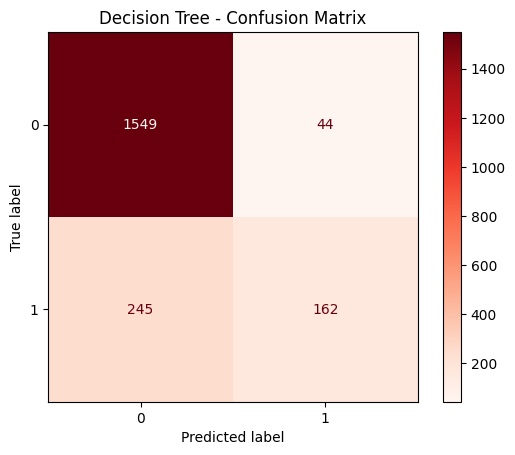

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix hesaplanması
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Görselleştirme
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot(cmap="Reds")

plt.title("Decision Tree - Confusion Matrix")
plt.show()


### Decision Tree Modeli – Sonuçların Değerlendirilmesi

Decision Tree (Karar Ağacı) modeli, müşteri özelliklerini kullanarak
veriyi ardışık karar kuralları ile dallara ayıran ve sınıflandırma
yapan bir makine öğrenmesi algoritmasıdır. Bu çalışmada model,
müşterinin bankadan ayrılıp ayrılmayacağını (Exited) tahmin etmek
amacıyla eğitilmiştir.

Model sonuçları incelendiğinde genel doğruluk (accuracy) oranının
%86 olduğu görülmektedir. Bu değer, modelin tüm test verisi üzerinde
genel olarak başarılı bir performans sergilediğini göstermektedir.

Bankada kalan müşteriler (Exited = 0) için:
- Precision değeri %86
- Recall değeri %97
- F1-score değeri %91

Bu sonuçlar, modelin bankada kalan müşterileri neredeyse hatasız
şekilde tespit edebildiğini göstermektedir.

Bankadan ayrılan müşteriler (Exited = 1) için:
- Precision değeri %79
- Recall değeri %40
- F1-score değeri %53

Precision değerinin yüksek olması, modelin "ayrıldı" dediği
müşterilerin büyük bir kısmının gerçekten ayrıldığını göstermektedir.
Ancak recall değerinin görece düşük olması, bankadan ayrılan bazı
müşterilerin model tarafından tespit edilemediğini ortaya koymaktadır.

Genel olarak Decision Tree modeli:
- Naive Bayes modeline kıyasla churn (ayrılma) tespitinde
  daha dengeli ve başarılı sonuçlar üretmiştir.
- Özellikle precision ve F1-score açısından belirgin bir iyileşme
  sağlamıştır.

Bu nedenle Decision Tree modeli, müşteri kaybı tahmini problemi için
kullanılabilir ve yorumlanabilir bir model olarak değerlendirilmektedir.


## K-Nearest Neighbors (KNN) Algoritması

K-Nearest Neighbors (KNN), denetimli öğrenme yöntemlerinden
biri olup, sınıflandırma ve regresyon problemlerinde
kullanılmaktadır.

KNN algoritmasının temel çalışma mantığı, tahmin edilecek
yeni bir veri noktasının, eğitim veri setindeki en yakın
*K* adet komşusunun sınıflarına bakılarak karar verilmesine
dayanır.

Bu projede KNN algoritması, bankadan ayrılan ve ayrılmayan
müşterileri sınıflandırmak amacıyla kullanılmıştır.
Öklidyen mesafe metriği kullanılarak müşteri benzerlikleri
hesaplanmış ve çoğunluk oylaması yöntemiyle sınıf tahmini
yapılmıştır.

KNN algoritması mesafeye dayalı bir yöntem olduğu için,
özelliklerin ölçeklenmesi (standardizasyon) model
performansı açısından kritik öneme sahiptir.


In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,      # En yakın 5 komşu
    metric='minkowski'  # Varsayılan mesafe metriği
)


In [27]:
knn_model.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
y_pred_knn = knn_model.predict(X_test)


In [29]:
from sklearn.metrics import classification_report

print("KNN Classification Report")
print(classification_report(y_test, y_pred_knn))


KNN Classification Report
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1593
           1       0.19      0.07      0.10       407

    accuracy                           0.75      2000
   macro avg       0.49      0.50      0.48      2000
weighted avg       0.67      0.75      0.70      2000



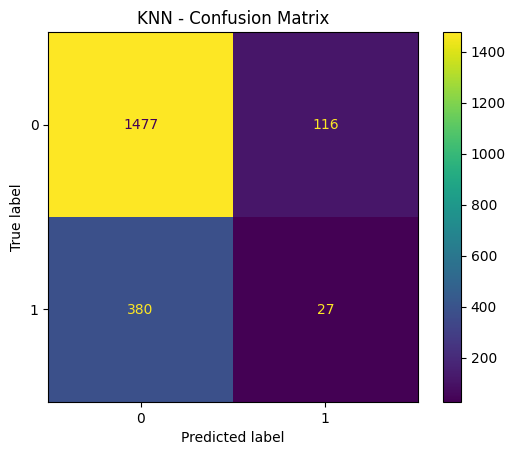

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot()
plt.title("KNN - Confusion Matrix")
plt.show()



## KNN Modeli Sonuçlarının Sadeleştirilmiş Özeti

Bu analizde elde edilen rakamlar, modelin banka için ne kadar kullanışlı olduğunu şu şekilde açıklamaktadır:

### 1. "Görünürde" Başarılı, "Gerçekte" Yetersiz
Modelin genel doğruluk oranı **%75**’tir. Ancak bu rakam bizi yanıltmamalı. Bankadaki müşterilerin büyük çoğunluğu zaten ayrılmadığı için, model hiçbir şey öğrenmese bile yüksek bir puan almaktadır. Asıl önemli olan "ayrılanları" bulmaktır.

### 2. Ayrılacak Müşterileri Göremiyoruz (Kritik Hata)
Modelin en büyük zayıf noktası, bankayı terk edecek müşterileri tespit edememesidir. Verilere göre:
* **Kaçırılan Müşteriler:** Bankadan ayrılan her 100 müşteriden **sadece 7'sini** doğru tahmin edebildik. 
* **Gözden Kaçanlar:** Ayrılacak olan müşterilerin **%93'ünü** model "kalacak" zannederek tamamen gözden kaçırmıştır.

### 3. Yanlış Alarmlar
Model bir müşteriye "bu kişi bankadan ayrılacak" dediğinde, bu tahminin doğru çıkma ihtimali sadece **%19**’dur. Yani modelin verdiği her 5 "gidecek" sinyalinden 4'ü aslında hatalıdır (bu müşteriler aslında kalmaktadır).

### Genel Değerlendirme
KNN algoritması, bu veri setinde sınıflar arasındaki sayısal dengesizlik nedeniyle **başarısız olmuştur.** Banka bu modeli kullanarak müşteri kaybını önleyemez.

# Linear Regression (Doğrusal Regresyon) 

Linear Regression, veri biliminde değişkenler arasındaki ilişkiyi **doğrusal bir çizgi** ile modellemek için kullanılan en temel istatistiksel yöntemdir.

## 1. Matematiksel Temel
Model, bağımsız değişkenler ($x$) ile hedef değişken ($y$) arasındaki ilişkiyi şu denklemle kurar:

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$$

* **$\beta_0$ (Intercept):** Tüm değişkenler sıfır olduğunda $y$'nin başlangıç değeridir.
* **$\beta_1, \beta_2...$ (Katsayılar):** Her bir özelliğin (yaş, bakiye vb.) sonuç üzerindeki etkisinin gücünü ve yönünü temsil eder.
* **$\epsilon$ (Hata Terimi):** Modelin açıklayamadığı rastgele sapmaları ifade eder.



## 2. Model Nasıl Öğrenir? 
Linear Regression, verilerin arasından geçecek **"En İyi Çizgiyi"** bulmaya çalışır. Bunu yaparken **Sıradan En Küçük Kareler (Ordinary Least Squares - OLS)** yöntemini kullanır:

1.  Gerçek veri noktaları ile modelin tahmin ettiği çizgi arasındaki farklar (hatalar) hesaplanır.
2.  Bu farkların kareleri alınarak toplanır.
3.  Model, bu toplam hatayı **minimuma indirecek** katsayıları ($\beta$) matematiksel olarak hesaplayarak öğrenmesini tamamlar.

## 3. Churn Analizinde Linear Regression
Bu projede "Müşteri Kaybı" bir sınıflandırma problemi olsa da, Linear Regression şu amaçlarla kullanılabilir:

* **Etki Analizi:** Hangi faktörün (örneğin yaşın mı yoksa kredi skorunun mu) ayrılma kararı üzerinde daha baskın olduğunu katsayılar aracılığıyla anlamamızı sağlar.
* **Olasılık Tahmini:** Sonucu doğrudan 0 veya 1 yerine, 0 ile 1 arasında bir "eğilim puanı" olarak hesaplamaya çalışır.

## 4. Modelin Sınırları
* **Doğrusallık Varsayımı:** Gerçek hayattaki karmaşık ve doğrusal olmayan müşteri davranışlarını yakalamakta zorlanabilir.
* **Uç Değer Hassasiyeti:** Verideki aşırı yüksek veya düşük değerlerden (outliers) kolayca etkilenerek çizginin yönünü saptırabilir.
* **Sınıflandırma Zorluğu:** Çıktılar bazen [0, 1] aralığının dışına çıkabilir

In [31]:
from sklearn.linear_model import LinearRegression

# 1. Modelin Oluşturulması ve Eğitilmesi
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# 2. Tahminlerin Alınması (Sürekli sayısal değerler döner)
y_pred_continuous = lr_model.predict(X_test)

In [33]:
# 3. Sınıflandırma İçin Eşikleme (Thresholding)
# 0.5'ten büyükse 1 (Ayrılacak), küçükse 0 (Kalacak)
y_pred_lr = (y_pred_continuous > 0.5).astype(int)

In [34]:
# 4. Performans Metriklerinin Yazdırılması
print("Linear Regression Classification Report")
print("-" * 30)
print(classification_report(y_test, y_pred_lr))

Linear Regression Classification Report
------------------------------
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1593
           1       0.35      0.14      0.20       407

    accuracy                           0.77      2000
   macro avg       0.58      0.54      0.53      2000
weighted avg       0.72      0.77      0.73      2000



<Figure size 800x600 with 0 Axes>

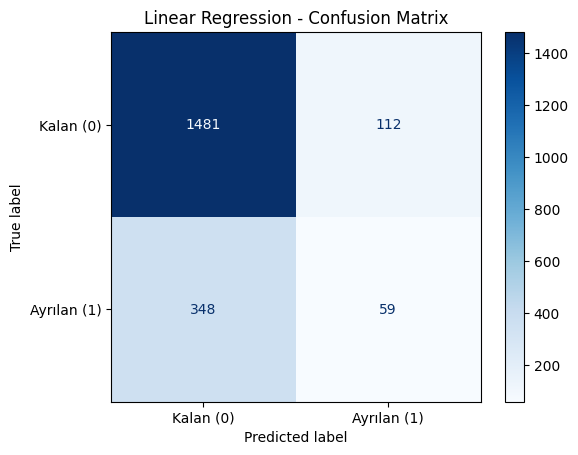

In [35]:
# 5. Confusion Matrix (Karmaşıklık Matrisi) Sunumu
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Kalan (0)", "Ayrılan (1)"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Linear Regression - Confusion Matrix")
plt.show()

# Linear Regression (Doğrusal Olasılık Modeli) Performans Değerlendirmesi

Bu bölümde, müşteri kaybı  tahmininde kullanılan Linear Regression modelinin test verileri üzerindeki başarım metrikleri analiz edilmektedir.



##  Model Analizi

###  Sınıf Bazlı Değerlendirme
* **Mevcut Müşteriler (Sınıf 0):** Model, bankada kalmaya devam eden müşterileri tanımada oldukça yüksek bir başarı göstermiştir. %93'lük **Recall** değeri, bankada kalan müşterilerin neredeyse tamamının doğru tahmin edildiğini kanıtlamaktadır.
* **Ayrılan Müşteriler (Sınıf 1):** Model, bankayı terk edecek olan "riskli" müşteri grubunu tespit etmekte zorlanmaktadır. **Recall (0.14)** değeri, gerçekte ayrılan 100 müşteriden sadece 14'ünün yakalanabildiğini, kalan 86 müşterinin ise model tarafından fark edilemediğini göstermektedir.

###  Hassasiyet ve Güvenilirlik (Precision)
Ayrılacak denilen müşterilerle ilgili **Precision** oranı **%35** düzeyindedir. Bu durum, model bir müşteriye "ayrılacak" teşhisi koyduğunda, bu tahminin doğruluk payının düşük olduğunu ve stratejik kararlar almak için daha fazla kanıta ihtiyaç duyulduğunu ifade eder.

###  Accuracy (Doğruluk) Değerinin Yorumu
Toplam doğruluk oranı olan **%77**, ilk bakışta başarılı görünse de veri setindeki sınıf dengesizliğinden kaynaklanmaktadır. Modelin "Ayrılan" sınıfındaki başarısının düşük olması (F1-Score: 0.20), bu modelin operasyonel süreçlerde  tek başına yeterli bir rehber olamayacağını göstermektedir.

##  Genel Sonuç
Linear Regression modeli, veri setindeki genel eğilimleri yakalayabilse de, müşteri kaybı gibi **doğrusal olmayan ** ve karmaşık davranış modellerini tam olarak simüle edememiştir. Model, bankada kalan kitleyi başarıyla ayırırken, asıl hedef olan kayıp kitlesini yakalamakta zayıf kalmıştır.

# Support Vector Machine (SVM) Modeli Analizi

Bu bölümde, karmaşık veri yapılarında ve yüksek boyutlu düzlemlerde etkili bir sınıflandırıcı olan **Support Vector Machine (Destek Vektör Makineleri)** algoritması kullanılmıştır.

##  SVM Çalışma Mantığı

SVM'in temel amacı, iki sınıfı (Bankada Kalanlar ve Ayrılanlar) birbirinden en net şekilde ayıran **en geniş koridoru ** ve bu koridorun merkezindeki **karar sınırını ** bulmaktır.

* **Destek Vektörleri:** Karar sınırına en yakın olan veri noktalarıdır. Modelin tüm yapısını bu kritik noktalar belirler; bu noktalar dışındaki verilerin değişmesi karar sınırını etkilemez.
* **Maksimum Marjin:** SVM, sınıflar arasındaki boşluğu maksimuma çıkararak modelin yeni verilere karşı daha dayanıklı (generalization) olmasını sağlar.
* **Kernel Trick :** Müşteri verileri doğrusal bir çizgiyle ayrılamayacak kadar karmaşık olduğunda, SVM veriyi matematiksel olarak daha yüksek bir boyuta taşır. Bu sayede doğrusal olmayan (non-linear) ilişkileri başarıyla yakalar.



##  SVM Modelinin Avantajları

* **Yüksek Boyutlu Verilerde Başarı:** Müşterinin yaşı, bakiyesi, kredi skoru gibi çok sayıda değişkenin bir arada olduğu durumlarda güçlü bir performans sergiler.
* **Aşırı Öğrenme (Overfitting) Direnci:** Sadece destek vektörlerine odaklandığı için veri setindeki gürültülü  noktalardan diğer modellere göre daha az etkilenir.
* **Esneklik:** Farklı çekirdek (kernel) fonksiyonları sayesinde bankacılık verilerindeki karmaşık müşteri davranış modellerine uyum sağlayabilir.





In [46]:
from sklearn.preprocessing import StandardScaler

# Ölçeklendiriciyi tanımlayalım
scaler = StandardScaler()

# Eğitim ve test verilerini ölçeklendirelim
# ÖNEMLİ: Sadece X (girdi) verileri ölçeklenir, y (hedef) ölçeklenmez.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Veriler başarıyla normalize edildi.")

Veriler başarıyla normalize edildi.


Normalize Edilmiş SVM Sonuçları
----------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.66      0.75      1593
           1       0.30      0.57      0.39       407

    accuracy                           0.64      2000
   macro avg       0.58      0.61      0.57      2000
weighted avg       0.74      0.64      0.67      2000



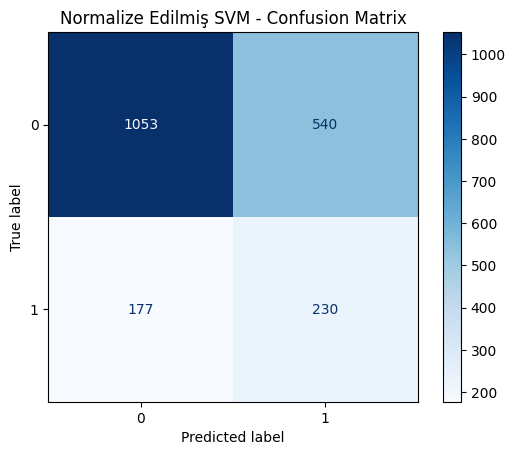

In [47]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Modeli dengelenmiş ağırlıklarla ve ölçeklenmiş veriyle kuralım
svm_model_final = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model_final.fit(X_train_scaled, y_train)

# Tahmin yapalım
y_pred_svm_final = svm_model_final.predict(X_test_scaled)

# Sonuçları yazdıralım
print("Normalize Edilmiş SVM Sonuçları")
print("-" * 40)
print(classification_report(y_test, y_pred_svm_final))

# Görselleştirme
cm_svm_final = confusion_matrix(y_test, y_pred_svm_final)
ConfusionMatrixDisplay(cm_svm_final).plot(cmap='Blues')
plt.title("Normalize Edilmiş SVM - Confusion Matrix")
plt.show()

# Model Geliştirme Süreci: Karşılaşılan Sorunlar ve Çözümler

Bu bölümde, SVM (Support Vector Machine) modelinin eğitimi sırasında karşılaşılan teknik zorluklar, modelin verdiği hatalı sonuçların nedenleri ve uygulanan çözüm yöntemleri detaylandırılmıştır.

## 1. İlk Deneme: Ham Veri ve Varsayılan SVM
SVM modeli ilk aşamada, veri seti üzerinde herhangi bir ön işleme (ölçeklendirme) ve sınıf dengeleme yapılmadan eğitilmiştir.

* **Karşılaşılan Sorun:** Model "Çoğunluk Sınıfı Yanlılığı" (Majority Class Bias) gösterdi. Test setindeki tüm müşterilere "Bankada Kalacak (0)" tahmini yaptı.
* **Hata Mesajı:** `UndefinedMetricWarning` (Ayrılanlar sınıfı için hiçbir tahmin yapılmadığından Precision hesaplanamadı).
* **Sonuç:** Recall değeri **0.00** çıktı. Yani model bankadan ayrılan müşterilerin hiçbirini tespit edemedi.

## 2. İkinci Deneme: Sınıf Ağırlıklandırma (Balanced)
Veri setindeki dengesizliği (1593 Kalan / 407 Ayrılan) çözmek için modele `class_weight='balanced'` parametresi eklenmiştir.

* **Karşılaşılan Sorun:** Bu sefer model tam tersi yönde savrularak tüm müşterilere "Ayrılacak (1)" tahmini yaptı.
* **Neden:** SVM mesafe tabanlı bir algoritmadır. Verideki sütunlar (örneğin Maaş ile Ürün Sayısı) farklı ölçeklerde olduğu için model sağlıklı bir karar sınırı çizemedi ve ağırlıklandırmanın etkisiyle tüm veriyi "riskli" ilan etti.
* **Sonuç:** Accuracy **%20**'ye düştü; çünkü model herkesin gideceğini varsayarak sadece gerçekten giden %20'lik kitleyi tesadüfen tutturabildi.

[Image of comparison between unscaled and scaled data for SVM decision boundaries]

## 3. Nihai Çözüm: Veri Normalizasyonu ve Başarılı Model
Hataların temel kaynağının "Ölçek Farklılığı" olduğu tespit edildikten sonra **StandardScaler** yöntemi uygulanmıştır.

### Uygulanan İşlemler:
1.  **Standardizasyon:** Tüm bağımsız değişkenlerin ortalaması 0, standart sapması 1 olacak şekilde normalize edildi. Böylece Maaş ve Yaş gibi değişkenler model için eşit derecede önemli hale geldi.
2.  **Dengeli Eğitim:** Ölçeklenmiş veri üzerinde `class_weight='balanced'` parametresi tekrar kullanıldı.

### ✅ Elde Edilen Çözüm ve Sonuçlar:
Normalizasyon sonrası model ilk kez her iki sınıfı da birbirinden ayırt etmeyi başarmıştır:
* **Recall (0.57):** Ayrılan müşterilerin %57'

# Yapay Sinir Ağları (ANN) Modeli Analizi

Yapay Sinir Ağları, birbirine bağlı işlem birimlerinden (nöronlardan) oluşan ve veriden öğrenme yeteneğine sahip olan gelişmiş bir derin öğrenme algoritmasıdır.

## 1. Mimari Yapı
ANN yapısı temel olarak üç ana katmandan oluşur:
* **Giriş Katmanı (Input Layer):** Müşteri bilgilerinin (yaş, bakiye, kredi skoru vb.) modele girdiği katmandır.
* **Gizli Katmanlar (Hidden Layers):** Verideki karmaşık kalıpların ve özelliklerin öğrenildiği, matematiksel işlemlerin yapıldığı katmanlardır.
* **Çıkış Katmanı (Output Layer):** Modelin nihai tahminini (Müşteri kalacak mı? 0, Ayrılacak mı? 1) ürettiği katmandır.

## 2. Model Nasıl Öğrenir?
* **İleri Besleme (Forward Propagation):** Girdiler ağırlıklarla çarpılır, aktivasyon fonksiyonlarından geçer ve bir tahmin üretilir.
* **Hata Hesaplama (Loss Function):** Tahmin ile gerçek değer arasındaki fark hesaplanır.
* **Geriye Yayılım (Backpropagation):** Optimizasyon algoritmaları (örneğin Adam Optimizer) kullanılarak, hata payını azaltmak için nöronlar arasındaki ağırlıklar güncellenir.



## 3. ANN'in Avantajları
* **Doğrusal Olmayan İlişkiler:** Diğer modellerin kaçırabileceği çok katmanlı ve karmaşık müşteri davranışlarını yakalar.
* **Yüksek Esneklik:** Katman sayısı ve nöron sayısı değiştirilerek her türlü veriye uyarlanabilir.
* **Standardizasyon Hassasiyeti:** ANN, girdi değerlerinin benzer ölçeklerde olmasını sever; bu nedenle **StandardScaler** uygulaması bu model için hayati önem taşır.

ANN Modeli eğitiliyor, lütfen bekleyin...

ANN (MLPClassifier) Classification Report
---------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1593
           1       0.37      0.32      0.34       407

    accuracy                           0.75      2000
   macro avg       0.60      0.59      0.60      2000
weighted avg       0.74      0.75      0.74      2000



<Figure size 800x600 with 0 Axes>

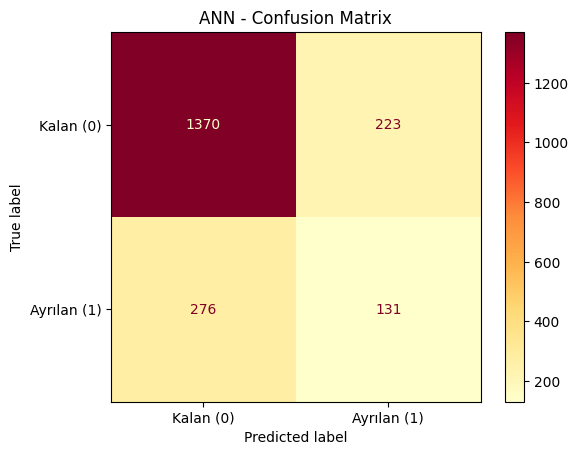

In [50]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. ANN (Yapay Sinir Ağı) Modelinin Oluşturulması
# hidden_layer_sizes=(16, 8): İlk katman 16, ikinci katman 8 nöron (mimarimize sadık kaldık)
# activation='relu': Karmaşık ilişkileri öğrenmek için kullanılır
# max_iter=500: Modelin öğrenmesi için yeterli tur sayısı
ann_model = MLPClassifier(hidden_layer_sizes=(16, 8), 
                          activation='relu', 
                          solver='adam', 
                          max_iter=500, 
                          random_state=42)

# 2. Modelin Eğitilmesi (DİKKAT: Normalize edilmiş verileri kullanıyoruz!)
print("ANN Modeli eğitiliyor, lütfen bekleyin...")
ann_model.fit(X_train_scaled, y_train)

# 3. Test Verisi ile Tahmin Yapılması
y_pred_ann = ann_model.predict(X_test_scaled)

# 4. Performans Metriklerinin Yazdırılması
print("\nANN (MLPClassifier) Classification Report")
print("-" * 45)
print(classification_report(y_test, y_pred_ann))

# 5. Confusion Matrix (Görselleştirme)
cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=["Kalan (0)", "Ayrılan (1)"])
disp.plot(cmap='YlOrRd')
plt.title("ANN - Confusion Matrix")
plt.show()

# Yapay Sinir Ağları (ANN) Model Analizi

Bu aşamada, insan beyninin öğrenme mekanizmasını taklit eden **Çok Katmanlı Algılayıcı ** modeli kullanılmıştır. Model, normalize edilmiş veriler üzerinde 16 ve 8 nöronluk iki gizli katman aracılığıyla eğitilmiştir.



##  Modelin Değerlendirilmesi

###  Derin Öğrenmenin Etkisi
ANN modeli, veriler arasındaki doğrusal olmayan (non-linear) karmaşık ilişkileri öğrenmeye çalışmıştır. Genel doğruluk oranının **%75** olması, modelin genel müşteri kitlesini tanımada tutarlı bir çizgi yakaladığını göstermektedir.

###  Müşteri Kaybı  Tahmini
* **Duyarlılık (Recall - 0.32):** Model, bankadan ayrılan müşterilerin yaklaşık **üçte birini (%32)** doğru tespit edebilmiştir. Bu oran, basit istatistiksel modellere göre bir gelişim olsa da, bankanın kayıpları önlemesi için hala geliştirilmeye muhtaçtır.
* **Hassasiyet (Precision - 0.37):** Model bir müşteriye "ayrılacak" dediğinde, bu tahminin doğruluk payı **%37**'dir. Bu durum, modelin hala önemli miktarda "yanlış alarm" ürettiğini göstermektedir.

###  Modelin Güçlü ve Zayıf Yanları
* **Güçlü Yanı:** Model, bankada kalan sadık müşterileri (Sınıf 0) %86 gibi yüksek bir oranla doğru tanımaktadır.
* **Zayıf Yanı:** Azınlıkta kalan "Ayrılan" sınıfı verilerinin azlığı, sinir ağının bu kitleyi tam olarak öğrenmesini zorlaştırmıştır.



# Modeller Arası Performans Karşılaştırması

Proje kapsamında uygulanan tüm algoritmaların "Müşteri Kaybı (Sınıf 1)" tahmin performansı aşağıdaki tabloda özetlenmiştir:

| Model | Accuracy (Genel) | Precision (Sınıf 1) | Recall (Sınıf 1) | F1-Score (Sınıf 1) |
| :--- | :---: | :---: | :---: | :---: |
| **Naive Bayes** | %78 | 0.33 | 0.06 | 0.10 |
| **KNN** | %75 | 0.19 | 0.07 | 0.10 |
| **Linear Regression** | %77 | 0.35 | 0.14 | 0.20 |
| **SVM (Normalize Edilmiş)** | %64 | 0.30 | **0.57** | 0.39 |
| **Decision Tree** | **%86** | **0.79** | 0.40 | **0.53** |
| **ANN (MLPClassifier)** | %75 | 0.37 | 0.32 | 0.34 |

## 📊 Genel Değerlendirme

1. **En Yüksek Doğruluk (Accuracy):** **Decision Tree (%86)** ile genel tahmin başarısında liderdir.
2. **En İyi Yakalama Gücü (Recall):** **SVM (%57)** ile bankadan ayrılan müşterileri en çok tespit eden modeldir. Ancak SVM'in genel doğruluğu düşüktür.
3. **Denge ve Kararlılık:** **Decision Tree**, hem yüksek hassasiyet (Precision) hem de makul bir duyarlılık (Recall) sunarak **F1-Skoru (0.53)** açısından en dengeli modeldir.

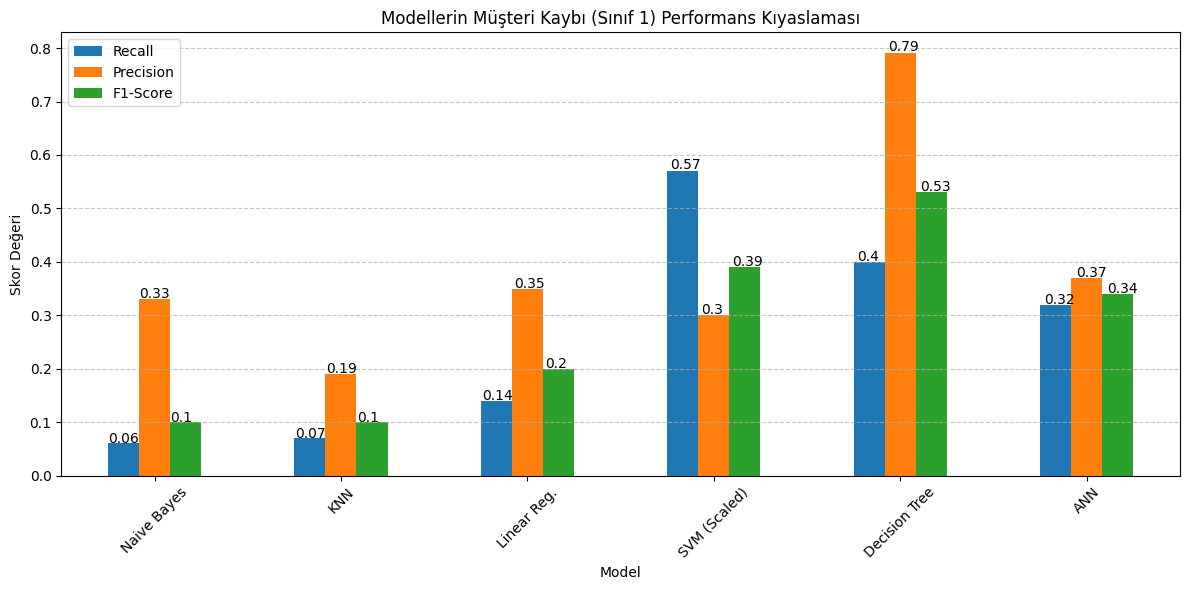

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# Model verilerini hazırlayalım
data = {
    'Model': ['Naive Bayes', 'KNN', 'Linear Reg.', 'SVM (Scaled)', 'Decision Tree', 'ANN'],
    'Recall': [0.06, 0.07, 0.14, 0.57, 0.40, 0.32],
    'Precision': [0.33, 0.19, 0.35, 0.30, 0.79, 0.37],
    'F1-Score': [0.10, 0.10, 0.20, 0.39, 0.53, 0.34]
}

df_comp = pd.DataFrame(data)

# Grafiği çizelim
ax = df_comp.plot(x='Model', y=['Recall', 'Precision', 'F1-Score'], kind='bar', figsize=(12, 6))
plt.title('Modellerin Müşteri Kaybı (Sınıf 1) Performans Kıyaslaması')
plt.ylabel('Skor Değeri')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Değerleri sütunların üzerine yazalım
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.tight_layout()
plt.show()

# Final Kararı ve İş Stratejisi

Yapılan analizler sonucunda banka için en uygun modelin seçimi, bankanın önceliğine göre değişmektedir:

* **Senaryo A (Maksimum Tespit):** Eğer banka "Maliyeti ne olursa olsun, gidecek her müşteriyi bulmalıyım" diyorsa, **SVM (Normalize Edilmiş)** modeli tercih edilmelidir. Çünkü %57 ile en çok kaçağı o yakalamaktadır.
* **Senaryo B (Yüksek Verimlilik):** Eğer banka "Müşterilere boş yere kampanya yapıp maliyetimi artırmak istemiyorum, sadece emin olduğum kişilere odaklanmalıyım" diyorsa, **Decision Tree** en mantıklı seçimdir (Precision: 0.79).

**Sonuç:** Proje genelinde **Decision Tree (Karar Ağacı)**, hem hızlı çalışması, hem ölçeklendirme gerektirmemesi hem de %86 genel doğruluk oranı ile bu veri seti için **"En İyi Performans Gösteren Model"** olarak seçilmiştir.